In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import rf_probability
import seaborn as sns

import joblib

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
X_train = pd.read_csv(
    "../data/X_train_smote.csv"
)

y_train = pd.read_csv(
    "../data/y_train_smote.csv"
).squeeze()

X_test = pd.read_csv(
    "../data/X_test.csv"
)

y_test = pd.read_csv(
    "../data/y_test.csv"
).squeeze()

print("Data loaded successfully!")

Data loaded successfully!


In [3]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (98550, 14)
y_train: (98550,)
X_test : (1272524, 14)
y_test : (1272524,)


In [4]:
print("Training distribution:")
print(y_train.value_counts())
print("Testing distribution:")
print(y_test.value_counts())

Training distribution:
isFraud
0    65700
1    32850
Name: count, dtype: int64
Testing distribution:
isFraud
0    1270881
1       1643
Name: count, dtype: int64


In [5]:
print("Number of features:", len(X_train.columns))

print("\nFeatures:")
for feature in X_train.columns:
    print(feature)

Number of features: 14

Features:
step
amount
oldbalanceOrg
newbalanceOrig
oldbalanceDest
newbalanceDest
isFlaggedFraud
balanceDiffOrig
balanceDiffDest
amountToOrigBalance
type_CASH_OUT
type_DEBIT
type_PAYMENT
type_TRANSFER


In [6]:
print(
    "Columns match:",
    list(X_train.columns) == list(X_test.columns)
)

Columns match: True


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest created.")

Random Forest created.


In [8]:
print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Training completed!")

Training Random Forest...
Training completed!


In [9]:
y_pred_default = rf_model.predict(
    X_test
)
print(y_pred_default[:20])

y_probability = rf_model.predict_proba(
    X_test
)[:, 1]
print(y_probability[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0.   0.   0.   0.   0.   0.   0.16 0.   0.02 0.   0.   0.   0.   0.
 0.   0.   0.   0.09 0.   0.  ]


In [10]:
print(
    pd.Series(y_probability).describe()
)

count    1.272524e+06
mean     3.346695e-03
std      3.915960e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
dtype: float64


In [11]:
threshold = 0.30

y_prediction = (
    y_probability >= threshold
).astype(int)

print(
    pd.Series(y_prediction).value_counts()
)

0    1270203
1       2321
Name: count, dtype: int64


In [12]:
accuracy = accuracy_score(
    y_test,
    y_prediction
)

print(
    f"Accuracy: {accuracy:.4f}"
)

precision = precision_score(
    y_test,
    y_prediction,
    zero_division=0
)

print(
    f"Precision: {precision:.4f}"
)

recall = recall_score(
    y_test,
    y_prediction,
    zero_division=0
)

print(
    f"Recall: {recall:.4f}"
)

f1 = f1_score(
    y_test,
    y_prediction,
    zero_division=0
)

print(
    f"F1 Score: {f1:.4f}"
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

Accuracy: 0.9995
Precision: 0.7070
Recall: 0.9988
F1 Score: 0.8280
ROC-AUC: 0.9996


In [13]:
cm = confusion_matrix(
    y_test,
    y_prediction
)

print(cm)

[[1270201     680]
 [      2    1641]]


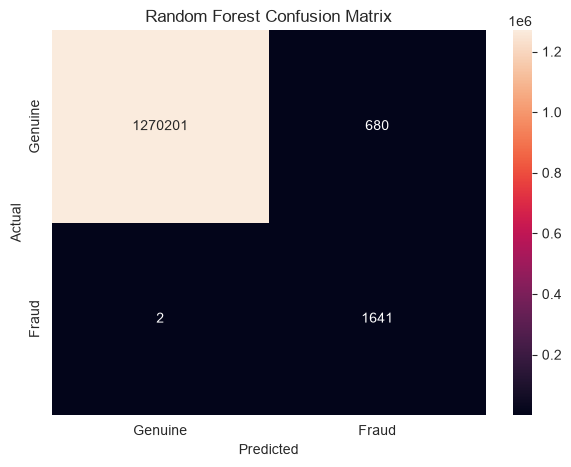

In [14]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
print(
    classification_report(
        y_test,
        y_prediction,
        target_names=[
            "Genuine",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00   1270881
       Fraud       0.71      1.00      0.83      1643

    accuracy                           1.00   1272524
   macro avg       0.85      1.00      0.91   1272524
weighted avg       1.00      1.00      1.00   1272524



In [16]:
thresholds = np.arange(
    0.10,
    0.61,
    0.05
)

threshold_results = []

for current_threshold in thresholds:

    predictions = (
        y_probability >= current_threshold
    ).astype(int)

    precision_value = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1_value = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": current_threshold,
        "precision": precision_value,
        "recall": recall_value,
        "f1": f1_value
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,threshold,precision,recall,f1
0,0.10,0.289520,0.998783,0.448913
1,0.15,0.488393,0.998783,0.656006
2,0.20,0.596510,0.998783,0.746928
3,0.25,0.667616,0.998783,0.800293
4,0.30,0.715344,0.998783,0.833630
5,0.35,0.750686,0.998783,0.857143
6,0.40,0.793520,0.998783,0.884398
7,0.45,0.834265,0.998783,0.909141
8,0.50,0.867795,0.998783,0.928693
9,0.55,0.888407,0.998174,0.940097


In [17]:
best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("Threshold with highest F1:")
print(best_row)

Threshold with highest F1:
threshold    0.600000
precision    0.910100
recall       0.998174
f1           0.952104
Name: 10, dtype: float64


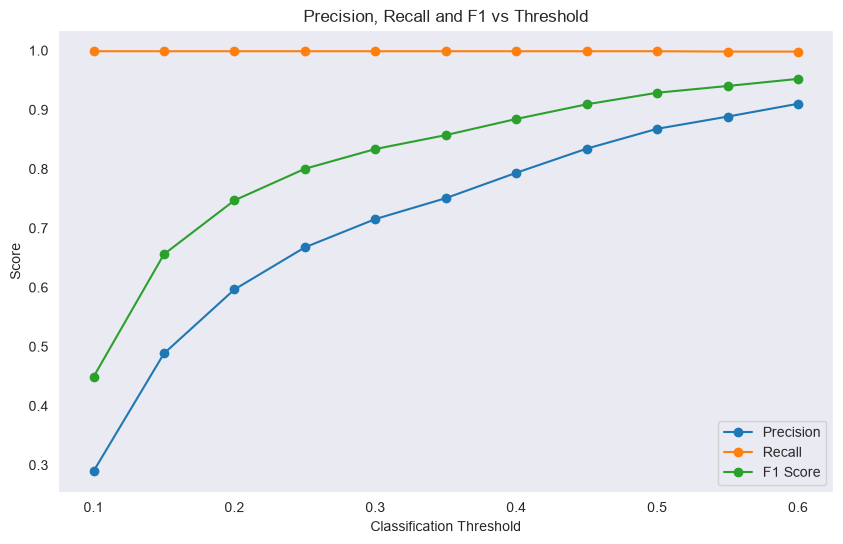

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Precision, Recall and F1 vs Threshold"
)

plt.legend()

plt.grid()

plt.show()

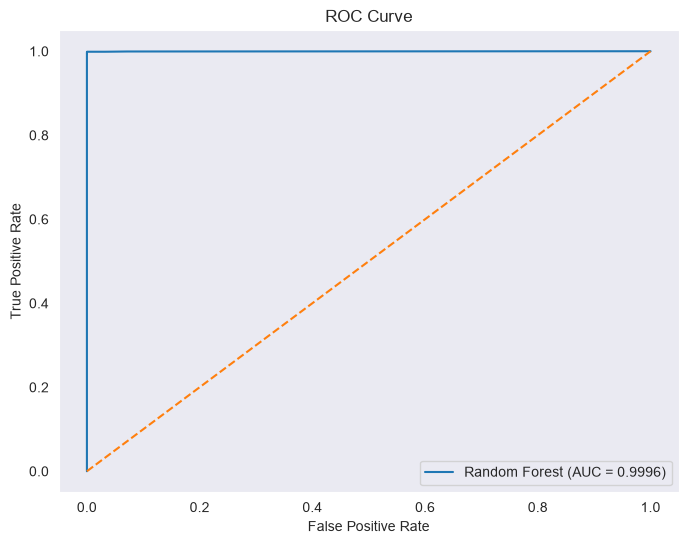

In [19]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [21]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )

    "XGBoost": XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
    )
}

In [23]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train,
        y_train
    )

    # Probability
    y_probability = model.predict_proba(
        X_test
    )[:, 1]

    # Use the same threshold
    threshold = 0.30

    y_prediction = (
        y_probability >= threshold
    ).astype(int)

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_prediction
    )

    precision = precision_score(
        y_test,
        y_prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_prediction,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"{name} completed.")


Training Logistic Regression...
Logistic Regression completed.

Training Decision Tree...
Decision Tree completed.

Training Random Forest...
Random Forest completed.

Training Gradient Boosting...
Gradient Boosting completed.


In [24]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.920465,0.015456,0.966525,0.030426,0.987668
1,Decision Tree,0.999365,0.671036,0.996957,0.802155,0.998162
2,Random Forest,0.999464,0.707023,0.998783,0.827952,0.999641
3,Gradient Boosting,0.999742,0.834265,0.998783,0.909141,0.999891


In [25]:
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_display[metric_columns] = (
    results_display[metric_columns]
    .round(4)
)

results_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9205,0.0155,0.9665,0.0304,0.9877
1,Decision Tree,0.9994,0.6710,0.9970,0.8022,0.9982
2,Random Forest,0.9995,0.7070,0.9988,0.8280,0.9996
3,Gradient Boosting,0.9997,0.8343,0.9988,0.9091,0.9999


In [26]:
results_percentage = results_df.copy()

for column in metric_columns:
    results_percentage[column] = (
        results_percentage[column] * 100
    ).round(2)

results_percentage

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,92.05,1.55,96.65,3.04,98.77
1,Decision Tree,99.94,67.10,99.70,80.22,99.82
2,Random Forest,99.95,70.70,99.88,82.80,99.96
3,Gradient Boosting,99.97,83.43,99.88,90.91,99.99


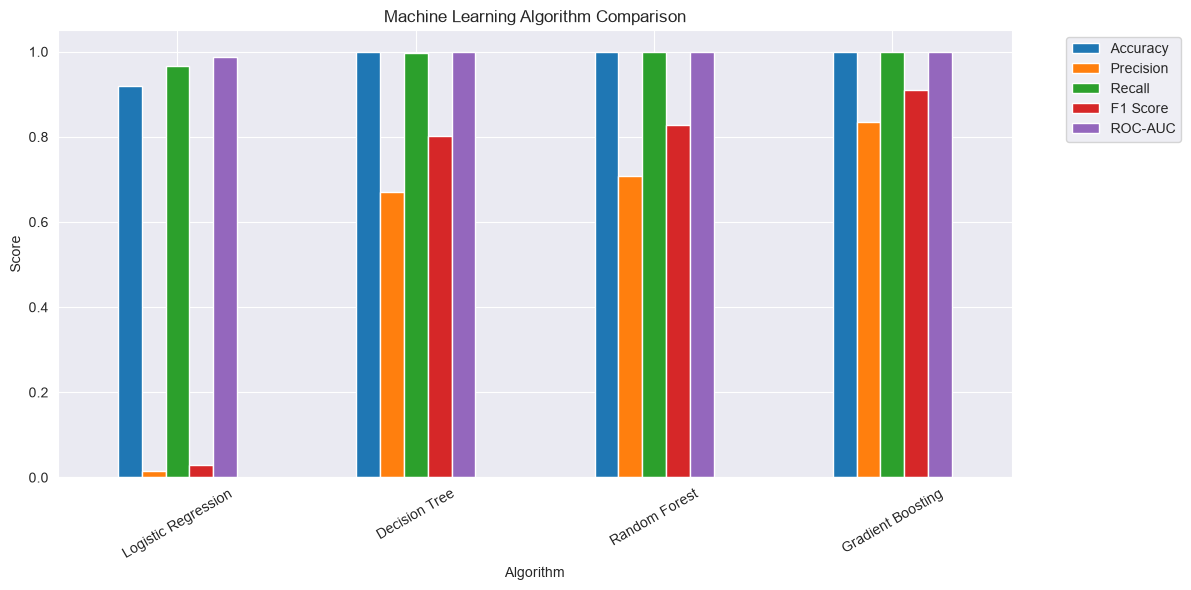

In [27]:
results_plot = results_df.set_index(
    "Model"
)

results_plot[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Machine Learning Algorithm Comparison"
)

plt.xlabel("Algorithm")
plt.ylabel("Score")

plt.xticks(rotation=30)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()